In [60]:
from rdkit import Chem
import os
import glob
import cirpy
from tqdm import tqdm
import pubchempy as pcp

run_no = 1

dirs = glob.glob(f"2D_mols/run_{run_no}/*/")
cas = [d.split("/")[-2].split()[0] for d in dirs]

for cas_no, d in tqdm(zip(cas, dirs), total=len(cas)):
    if os.path.exists(f"{os.path.join(d, cas_no)}.mol"):
        continue
    smiles = cirpy.resolve(cas_no, 'smiles')
    if smiles is None:
        pcp_compound = pcp.get_compounds(cas_no, 'name')
        if pcp_compound:
            smiles = pcp_compound[0].connectivity_smiles
            
    if smiles is None:
        print(f"Could not resolve SMILES for CAS {cas_no}")
        continue

    mol = Chem.AddHs(Chem.MolFromSmiles(smiles))
    if mol is None:
        continue
    
    
    # print(f"{os.path.join(d, cas_no)}.mol")
    Chem.MolToMolFile(mol, f"{os.path.join(d, cas_no)}.mol")

100%|██████████| 32/32 [00:00<00:00, 33.67it/s]

Could not resolve SMILES for CAS 913-90-1


In [129]:

all_mols = []
sps_scores = []
mol_ids = []

In [130]:
run_no = 4

In [131]:

## Mols so far

from rdkit import Chem
import os
import glob
import cirpy
from rdkit.Chem import SpacialScore
from tqdm import tqdm
import pubchempy as pcp
import pandas as pd


dirs = glob.glob(f"2D_mols/run_{run_no}/*/")
cas = [d.split("/")[-2].split()[0] for d in dirs]
ids = [d.split("/")[-2].split()[-1].split('(')[-1].split(')')[0] for d in dirs]
df = pd.read_excel(f"/Users/mx23826/Downloads/cheminventory_09_04_2026/sampled/sampled_df_run_{run_no}.xlsx")

# for cas_no, d in tqdm(zip(cas, dirs), total=len(cas)):
    # smiles = cirpy.resolve(cas_no, 'smiles')
    # if smiles is None:
    #     pcp_compound = pcp.get_compounds(cas_no, 'name')
    #     if pcp_compound:
    #         smiles = pcp_compound[0].connectivity_smiles
            
    # if smiles is None:
    #     print(f"Could not resolve SMILES for CAS {cas_no}")
    #     continue

    # mol = Chem.MolFromSmiles(smiles)
    # if mol is None:
    #     continue
    
for id in tqdm(ids, total=len(ids)):
    print(id)
    mol = Chem.MolFromSmiles(df[df['index'] == int(id)]['SMILES'].values[0])
    if mol is None:
        continue
    # print(f"{os.path.join(d, cas_no)}.mol")
    all_mols.append(mol)
    sps_score = SpacialScore.SPS(mol)
    sps_scores.append(sps_score)
    mol_ids.append(id)
    

100%|██████████| 40/40 [00:00<00:00, 1124.79it/s]

121
386
104
424
260
181
148
354
153
41
194
332
71
160
69
326
426
352
280
212
335
97
25
157
161
43
248
276
66
286
162
221
96
399
197
3
110
411
189
208


In [132]:
df = pd.DataFrame({
    "mol": all_mols,
    "sps_score": sps_scores,
    'SMILES': [Chem.MolToSmiles(mol) for mol in all_mols],
    'id': mol_ids
})

In [67]:
# from rdkit.Chem import Draw

# Draw.MolsToGridImage(all_mols, molsPerRow=8, subImgSize=(400, 400), useSVG=True)

import mols2grid

mols2grid.display(df, n_cols=12, size=(260, 180), n_items_per_page=120, subset=['sps_score'])

MolGridWidget()

In [133]:
mols_with_nitrogen = []

for idx, row in df.iterrows():
    mol = row['mol']
    id = row['id']
    for atom in mol.GetAtoms():
        if atom.GetSymbol() == 'N':
            mols_with_nitrogen.append(id)
            
mols_with_fluorine = []

for idx, row in df.iterrows():
    mol = row['mol']
    id = row['id']
    for atom in mol.GetAtoms():
        if atom.GetSymbol() == 'F':
            mols_with_fluorine.append(id)

mols_with_phosphorous = []

for idx, row in df.iterrows():
    mol = row['mol']
    id = row['id']
    for atom in mol.GetAtoms():
        if atom.GetSymbol() == 'P':
            mols_with_phosphorous.append(id)
            
mols_with_boron = []

for idx, row in df.iterrows():
    mol = row['mol']
    id = row['id']
    for atom in mol.GetAtoms():
        if atom.GetSymbol() == 'B':
            mols_with_boron.append(id)
            
mols_with_nitrogen = set(mols_with_nitrogen)
mols_with_fluorine = set(mols_with_fluorine)
mols_with_phosphorous = set(mols_with_phosphorous)
mols_with_boron = set(mols_with_boron)

In [134]:
mols_with_nitrogen

{'153', '181', '286', '335', '386', '399', '411'}

In [136]:
notebook_df = pd.read_excel(f"/Users/mx23826/Downloads/cheminventory_09_04_2026/sampled/notebook_df_run_{run_no}.xlsx", index_col=0)

import re

def extract_id(cell_value):
    match = re.search(r'\((\d+)\)', str(cell_value))
    return match.group(1) if match else None

for id in mols_with_nitrogen:
    matches = []
    for row_label, row in notebook_df.iterrows():
        for col_label in notebook_df.columns:
            cell_value = row[col_label]
            if extract_id(cell_value) == id:
                matches.append((row_label, col_label))

    print(f"ID: {id} Matching wells: {matches}")

ID: 411 Matching wells: [('C', 11)]
ID: 386 Matching wells: [('E', 9)]
ID: 335 Matching wells: [('D', 5)]
ID: 286 Matching wells: [('C', 9)]
ID: 399 Matching wells: [('B', 4)]
ID: 181 Matching wells: [('B', 8)]
ID: 153 Matching wells: [('A', 9)]


In [45]:
notebook_df

,Unnamed: 0,1,2,3,4,5,6,7,8,9,10,11,12
0,A,513-36-0\n (8486),None\n (1512),1450-14-2\n (4487),"['121-43-7', '31649-91-9', '63156-11-6']\n (6303)",106-30-9\n (3536),2483-14-9\n (3472),None\n (3926),16029-98-4\n (221),35234-88-9\n (4614),659-70-1\n (9185),None\n (1823),2412-80-8\n (2442)
1,B,None\n (3385),"['57352-34-8', '98-69-1']\n (5324)","['90-27-7', '14375-30-5', '7782-29-8']\n (7911)",132-32-1\n (4294),693-95-8\n (7845),321-28-8\n (2227),None\n (10221),None\n (5222),620-23-5\n (2013),116919-18-7\n (9689),None\n (6567),110-62-3\n (2191)
2,C,5704-04-1\n (8069),629-99-2\n (1955),3061-65-2\n (10177),None\n (4151),"['57214-71-8', '111-85-3']\n (634)","['23079-20-1', '7735-42-4']\n (9490)","['17465-86-0', '186903-59-3', '216309-81-8', '...",116-17-6\n (895),19009-39-3\n (5911),57199-00-5\n (6359),None\n (2103),475-31-0\n (2237)
3,D,16068-37-4\n (7594),1143-38-0\n (5919),None\n (1436),28920-43-6\n (3211),None\n (3793),90-99-3\n (469),None\n (6067),954-81-4\n (5931),"['19715-19-6', '96247-23-3']\n (10400)",None\n (6741),None\n (3170),None\n (5387)
4,E,None\n (10298),None\n (1034),None\n (9574),None\n (1891),"['86-53-3', '25551-35-3']\n (167)",None\n (6572),"['1080-16-6', '103-33-3', '17082-12-1']\n (1790)",None\n (9967),99685-96-8\n (6668),15854-87-2\n (6834),499-49-0\n (4850),28166-41-8\n (8322)
5,F,64248-62-0\n (6987),"['1914-58-5', '2243-53-0']\n (511)",21397-08-0\n (3522),87-48-9\n (3786),"['1218-34-4', '10385-85-0']\n (10500)",98-15-7\n (7207),121124-97-8\n (1552),763120-58-7\n (7216),69225-59-8\n (319),5895-35-2\n (4349),"['36536-46-6', '43137-57-1', '3068-88-0']\n (3...",4254-02-8\n (1695)


In [78]:
df['sps_score'].mean()

36.55444675456566

(array([ 3.,  5., 10.,  7.,  3.,  2.,  3.,  0.,  2.,  1.,  1.,  0.,  0.,
         0.,  0.,  1.,  0.,  1.,  0.,  1.]),
 array([ 5. ,  6.5,  8. ,  9.5, 11. , 12.5, 14. , 15.5, 17. , 18.5, 20. ,
        21.5, 23. , 24.5, 26. , 27.5, 29. , 30.5, 32. , 33.5, 35. ]),
 <BarContainer object of 20 artists>)

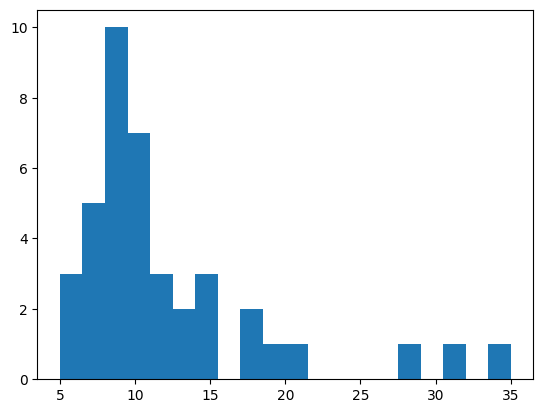

In [79]:
import matplotlib.pyplot as plt

nium_heavy_atoms = [mol.GetNumHeavyAtoms() for mol in all_mols]
plt.hist(nium_heavy_atoms, bins=20)

(array([6., 1., 1., 1., 4., 2., 3., 0., 2., 1., 0., 1., 0., 3., 5., 0., 2.,
        1., 5., 2.]),
 array([30.42857143, 31.05391705, 31.67926267, 32.30460829, 32.92995392,
        33.55529954, 34.18064516, 34.80599078, 35.43133641, 36.05668203,
        36.68202765, 37.30737327, 37.93271889, 38.55806452, 39.18341014,
        39.80875576, 40.43410138, 41.059447  , 41.68479263, 42.31013825,
        42.93548387]),
 <BarContainer object of 20 artists>)

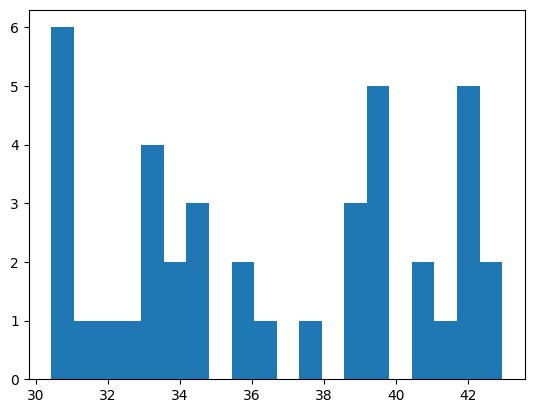

In [80]:
plt.hist(sps_scores, bins=20)

In [32]:
# Make .mol for mols without cas
mol = Chem.AddHs(Chem.MolFromSmiles('[H]c1c([H])c([H])c(C([H])([H])OC(=O)O[C@@]2([H])N([H])C(=O)C([H])([H])C2([H])[H])c([H])c1[H]'))
Chem.MolToMolFile(mol, f"2D_mols/run_{run_no}/(1705)/(1705).mol")
